# Inflation Burdern by Wealth Percentile

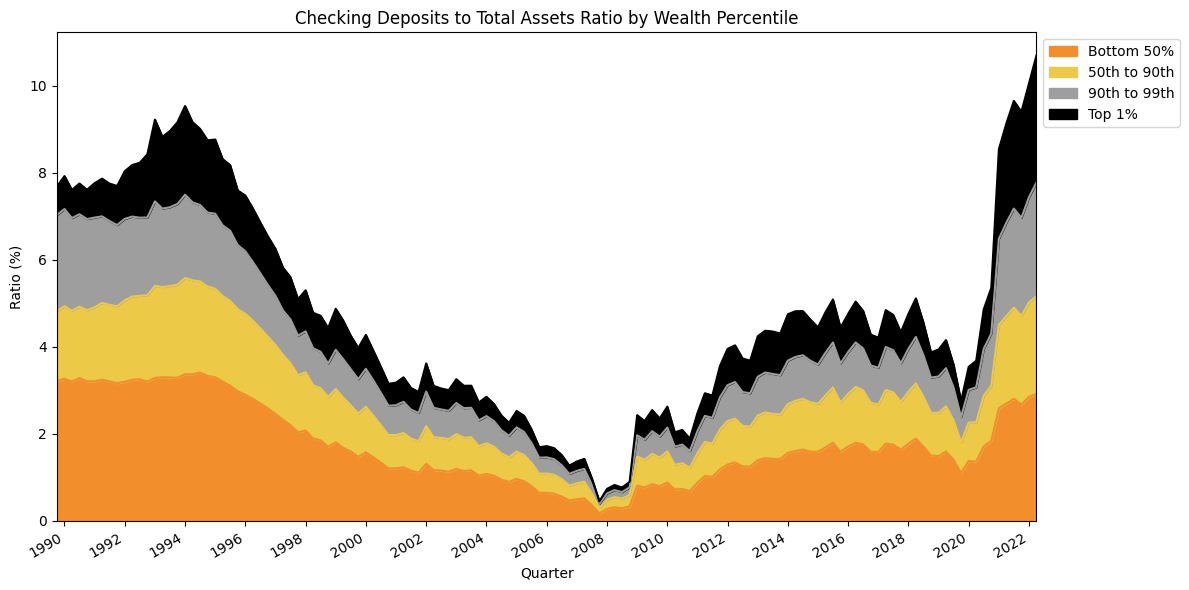

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def fred_series(series_id: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    # Normalize column names; some responses include whitespace or alternate labels.
    df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
    date_col = "DATE" if "DATE" in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.set_index(date_col)
    # Standardize the data column name to the series id and coerce missing values
    if series_id in df.columns:
        df = df.rename(columns={series_id: series_id})
    else:
        data_col = df.columns[0]
        df = df.rename(columns={data_col: series_id})
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df


# Fetch series as individual dataframes
WFRBSB50194 = fred_series("WFRBSB50194")
WFRBSN40167 = fred_series("WFRBSN40167")
WFRBSN09140 = fred_series("WFRBSN09140")
WFRBST01113 = fred_series("WFRBST01113")
WFRBSB50189 = fred_series("WFRBSB50189")
WFRBSN40162 = fred_series("WFRBSN40162")
WFRBSN09135 = fred_series("WFRBSN09135")
WFRBST01108 = fred_series("WFRBST01108")
BOGZ1FL193020005Q = fred_series("BOGZ1FL193020005Q")
BOGZ1FL192000005A = fred_series("BOGZ1FL192000005A")


def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Q")
    return out


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out


# Convert to period indexes
WFRBSB50194 = to_quarterly(WFRBSB50194)
WFRBSN40167 = to_quarterly(WFRBSN40167)
WFRBSN09140 = to_quarterly(WFRBSN09140)
WFRBST01113 = to_quarterly(WFRBST01113)
WFRBSB50189 = to_quarterly(WFRBSB50189)
WFRBSN40162 = to_quarterly(WFRBSN40162)
WFRBSN09135 = to_quarterly(WFRBSN09135)
WFRBST01108 = to_quarterly(WFRBST01108)

BOGZ1FL193020005Q = to_quarterly(BOGZ1FL193020005Q)
BOGZ1FL193020005Q = BOGZ1FL193020005Q[
    BOGZ1FL193020005Q.index >= pd.Period("1989Q3", freq="Q")
]

BOGZ1FL192000005A = to_annual(BOGZ1FL192000005A)
BOGZ1FL192000005A = BOGZ1FL192000005A[
    BOGZ1FL192000005A.index >= pd.Period("1989", freq="Y")
]

# Reindex annual data to Q3 and interpolate to quarterly frequency
annual = BOGZ1FL192000005A.copy()
annual.index = annual.index.year
annual_q3 = annual.copy()
annual_q3.index = pd.PeriodIndex([f"{y}Q3" for y in annual.index], freq="Q")
annual_q3 = annual_q3.sort_index()

full_quarters = pd.period_range(
    start=annual_q3.index.min(), end=annual_q3.index.max(), freq="Q"
)
BOGZ1FL192000005A_mod = annual_q3.reindex(full_quarters)
BOGZ1FL192000005A_mod = BOGZ1FL192000005A_mod.interpolate(method="linear")

# Build cashRatios dataframe
combined = pd.concat(
    [
        WFRBSB50194,
        WFRBSN40167,
        WFRBSN09140,
        WFRBST01113,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL193020005Q,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

cashRatios = pd.DataFrame(index=combined.index)

cashRatios["Bottom 50%"] = (
    combined["WFRBSB50194"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSB50189"] * combined["BOGZ1FL192000005A"])

cashRatios["50th to 90th"] = (
    combined["WFRBSN40167"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN40162"] * combined["BOGZ1FL192000005A"])

cashRatios["90th to 99th"] = (
    combined["WFRBSN09140"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN09135"] * combined["BOGZ1FL192000005A"])

cashRatios["Top 1%"] = (
    combined["WFRBST01113"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBST01108"] * combined["BOGZ1FL192000005A"])

# Express as percent
cashRatios = cashRatios * 100

# Stacked area chart
cashRatios_plot = cashRatios.copy()
cashRatios_plot.index = cashRatios_plot.index.to_timestamp(how="end")

# Ensure column order matches desired color order
cashRatios_plot = cashRatios_plot[["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]]

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = cashRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Checking Deposits to Total Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

# Tighten x-axis to data range and increase tick density to every 2 years
ax.set_xlim(cashRatios_plot.index.min(), cashRatios_plot.index.max())
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


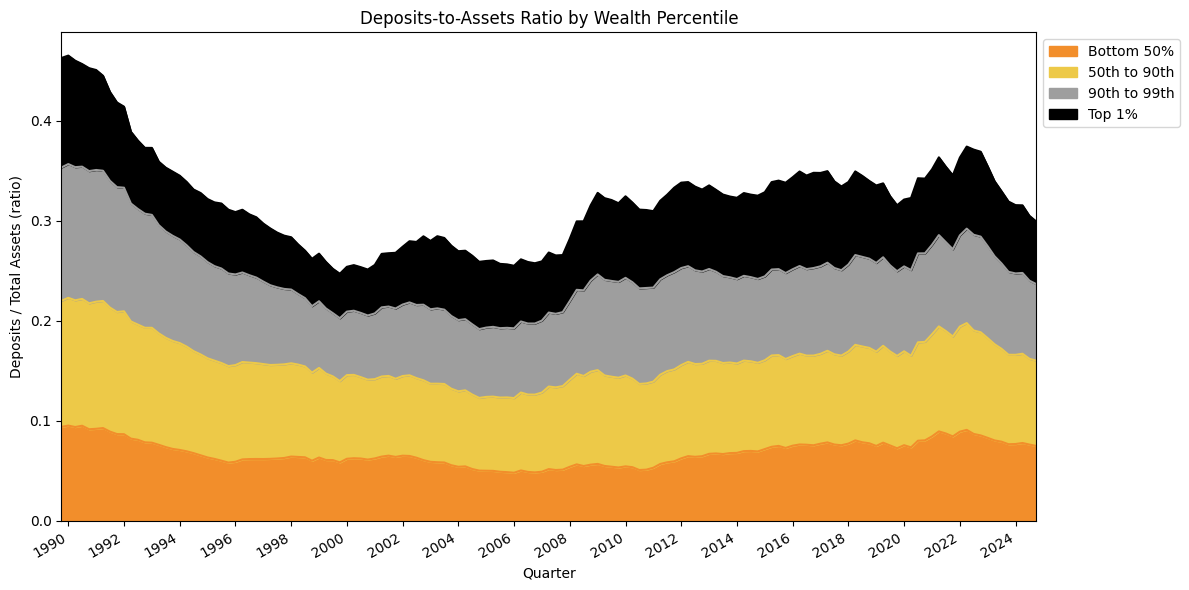

In [2]:
# Alternative chart: deposit level series as a share of total assets by percentile
WFRBLDEB50 = to_quarterly(fred_series("WFRBLDEB50"))
WFRBLDEN40 = to_quarterly(fred_series("WFRBLDEN40"))
WFRBLDEN09 = to_quarterly(fred_series("WFRBLDEN09"))
WFRBLTOP1DE = to_quarterly(fred_series("WFRBLTOP1DE"))

combined_deposits = pd.concat(
    [
        WFRBLDEB50,
        WFRBLDEN40,
        WFRBLDEN09,
        WFRBLTOP1DE,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

# Keep the same quarterly start point used in the first chart.
combined_deposits = combined_deposits[
    combined_deposits.index >= pd.Period("1989Q3", freq="Q")
]

depositAssetRatios = pd.DataFrame(index=combined_deposits.index)

depositAssetRatios["Bottom 50%"] = combined_deposits["WFRBLDEB50"] / (
    (combined_deposits["WFRBSB50189"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["50th to 90th"] = combined_deposits["WFRBLDEN40"] / (
    (combined_deposits["WFRBSN40162"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["90th to 99th"] = combined_deposits["WFRBLDEN09"] / (
    (combined_deposits["WFRBSN09135"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["Top 1%"] = combined_deposits["WFRBLTOP1DE"] / (
    (combined_deposits["WFRBST01108"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

# Keep as ratio values; e.g., 0.09 means 9%.

depositAssetRatios_plot = depositAssetRatios[
    ["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]
].copy()
depositAssetRatios_plot.index = depositAssetRatios_plot.index.to_timestamp(how="end")

import matplotlib.dates as mdates

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = depositAssetRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Deposits-to-Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Deposits / Total Assets (ratio)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

ax.set_xlim(depositAssetRatios_plot.index.min(), depositAssetRatios_plot.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


In [3]:
FEDFUNDS = fred_series("FEDFUNDS")

avg_fedfunds_rate = FEDFUNDS["FEDFUNDS"].dropna().mean()
start_date = FEDFUNDS.index.min().date()
end_date = FEDFUNDS.index.max().date()

print(
    f"Average FEDFUNDS rate over full history ({start_date} to {end_date}): "
    f"{avg_fedfunds_rate:.4f}%"
)


Average FEDFUNDS rate over full history (1954-07-01 to 2026-02-01): 4.6016%


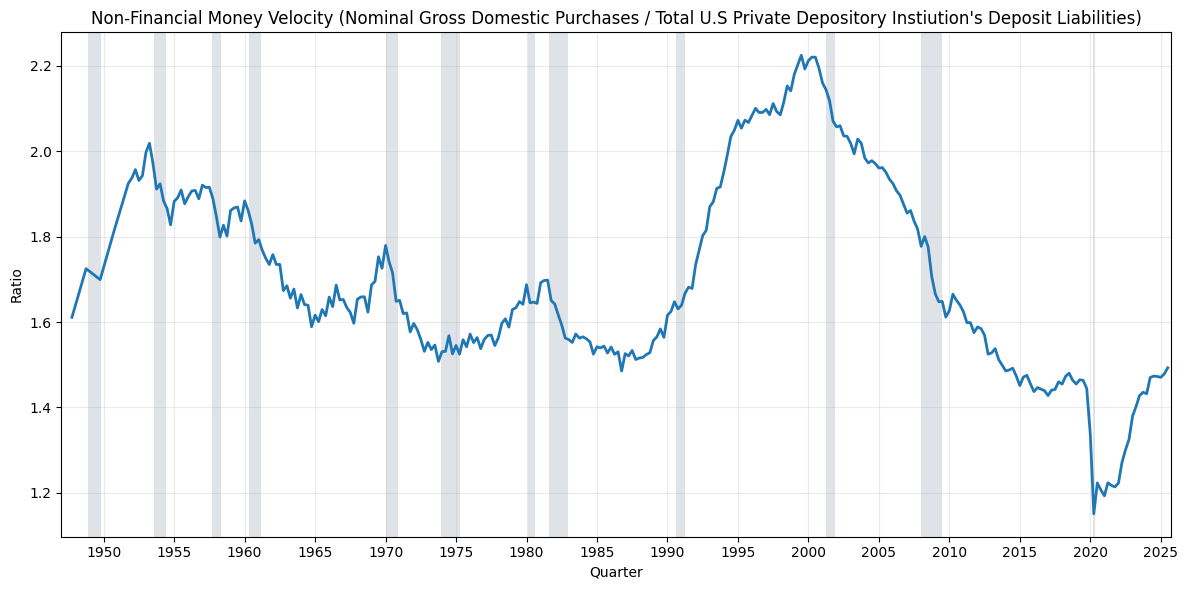

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()


def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    usrec = fred_series("USREC")
    rec = usrec["USREC"].dropna().astype(float)

    spans = []
    in_recession = False
    recession_start = None

    for dt, val in rec.items():
        if val >= 0.5 and not in_recession:
            recession_start = dt
            in_recession = True
        elif val < 0.5 and in_recession:
            spans.append((recession_start, dt))
            in_recession = False

    if in_recession and recession_start is not None:
        spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

    return spans


FSDP = to_quarterly(fred_series("FSDP"))
BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))

ratio_df = pd.concat([FSDP, BOGZ1FL703130005Q, BOGZ1FL703127005Q], axis=1).dropna()
ratio_df["ratio"] = (ratio_df["FSDP"] * 1000) / (
    ratio_df["BOGZ1FL703130005Q"] + ratio_df["BOGZ1FL703127005Q"]
)

start_q = pd.Period("1947Q1", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
ratio_window = ratio_df.loc[start_q:end_q, ["ratio"]].dropna()

ratio_plot = ratio_window.copy()
ratio_plot.index = ratio_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ratio_plot.index, ratio_plot["ratio"], color="#1f77b4", linewidth=2)
ax.set_title(
    "Non-Financial Money Velocity (Nominal Gross Domestic Purchases / "
    "Total U.S Private Depository Instiution's Deposit Liabilities)"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio")
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


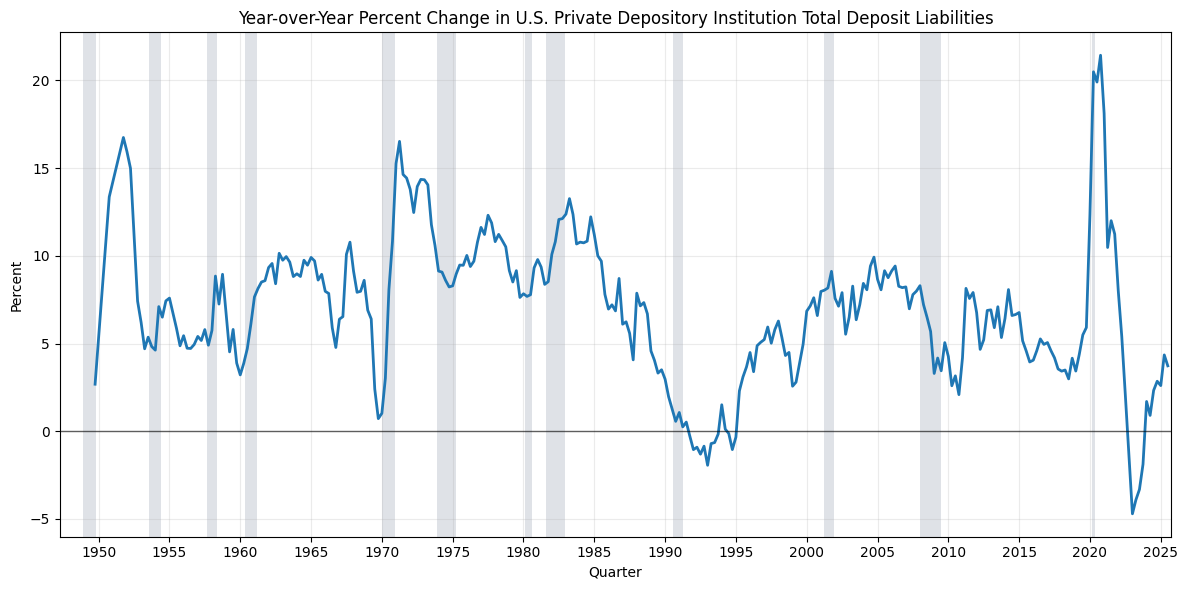

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()

if "us_recession_spans" not in globals():
    def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
        usrec = fred_series("USREC")
        rec = usrec["USREC"].dropna().astype(float)

        spans = []
        in_recession = False
        recession_start = None

        for dt, val in rec.items():
            if val >= 0.5 and not in_recession:
                recession_start = dt
                in_recession = True
            elif val < 0.5 and in_recession:
                spans.append((recession_start, dt))
                in_recession = False

        if in_recession and recession_start is not None:
            spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

        return spans


BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))

deposits_df = pd.concat([BOGZ1FL703130005Q, BOGZ1FL703127005Q], axis=1).dropna()
deposits_df["total_deposit_liabilities"] = (
    deposits_df["BOGZ1FL703130005Q"] + deposits_df["BOGZ1FL703127005Q"]
)

# Year-over-year percent change for quarterly data (t vs t-4).
deposits_df["yoy_pct_change"] = (
    (deposits_df["total_deposit_liabilities"] / deposits_df["total_deposit_liabilities"].shift(4)) - 1
) * 100

start_q = pd.Period("1947Q2", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
growth_window = deposits_df.loc[start_q:end_q, ["yoy_pct_change"]].dropna()

growth_plot = growth_window.copy()
growth_plot.index = growth_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    growth_plot.index,
    growth_plot["yoy_pct_change"],
    color="#1f77b4",
    linewidth=2,
)
ax.set_title(
    "Year-over-Year Percent Change in U.S. Private Depository "
    "Institution Total Deposit Liabilities"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Percent")
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


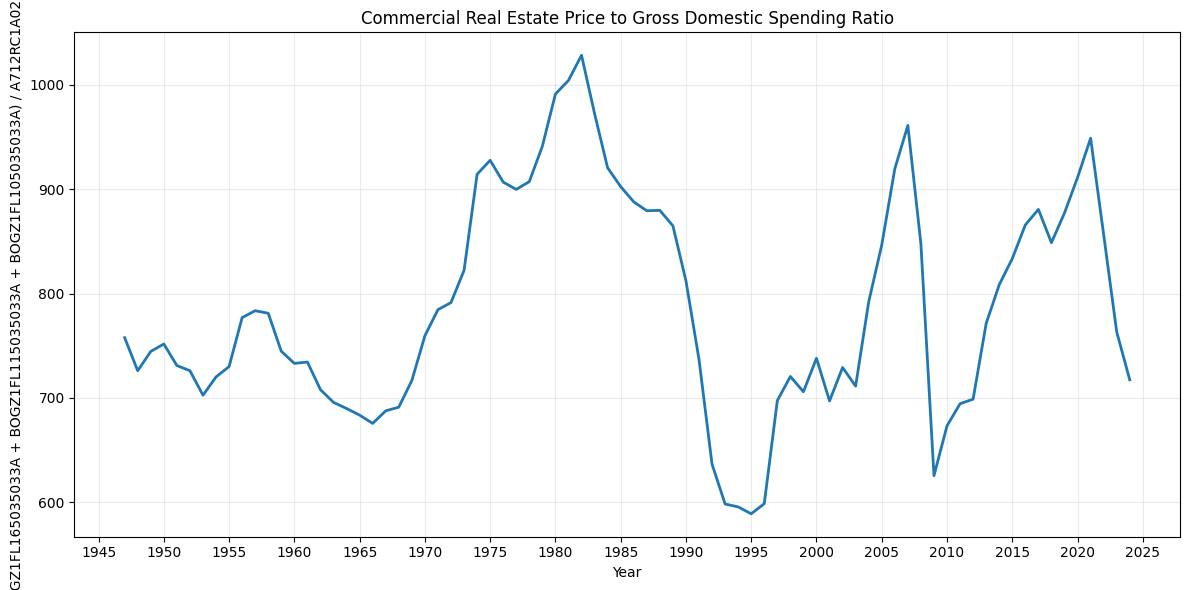

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


BOGZ1FL165035033A = to_annual(fred_series("BOGZ1FL165035033A"))
BOGZ1FL115035033A = to_annual(fred_series("BOGZ1FL115035033A"))
BOGZ1FL105035033A = to_annual(fred_series("BOGZ1FL105035033A"))
A712RC1A027NBEA = to_annual(fred_series("A712RC1A027NBEA"))

cre_ratio_df = pd.concat(
    [
        BOGZ1FL165035033A,
        BOGZ1FL115035033A,
        BOGZ1FL105035033A,
        A712RC1A027NBEA,
    ],
    axis=1,
).dropna()
cre_ratio_df = cre_ratio_df[cre_ratio_df["A712RC1A027NBEA"] != 0]
cre_ratio_df["CRE_Price_to_GDS_Ratio"] = (
    cre_ratio_df["BOGZ1FL165035033A"]
    + cre_ratio_df["BOGZ1FL115035033A"]
    + cre_ratio_df["BOGZ1FL105035033A"]
) / cre_ratio_df["A712RC1A027NBEA"]

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2024", freq="Y")
cre_price_to_gds_ratio = cre_ratio_df.loc[start_y:end_y, "CRE_Price_to_GDS_Ratio"].dropna()

plot = cre_price_to_gds_ratio.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
ax.set_title("Commercial Real Estate Price to Gross Domestic Spending Ratio")
ax.set_xlabel("Year")
ax.set_ylabel(
    "(BOGZ1FL165035033A + BOGZ1FL115035033A + BOGZ1FL105035033A) / A712RC1A027NBEA"
)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


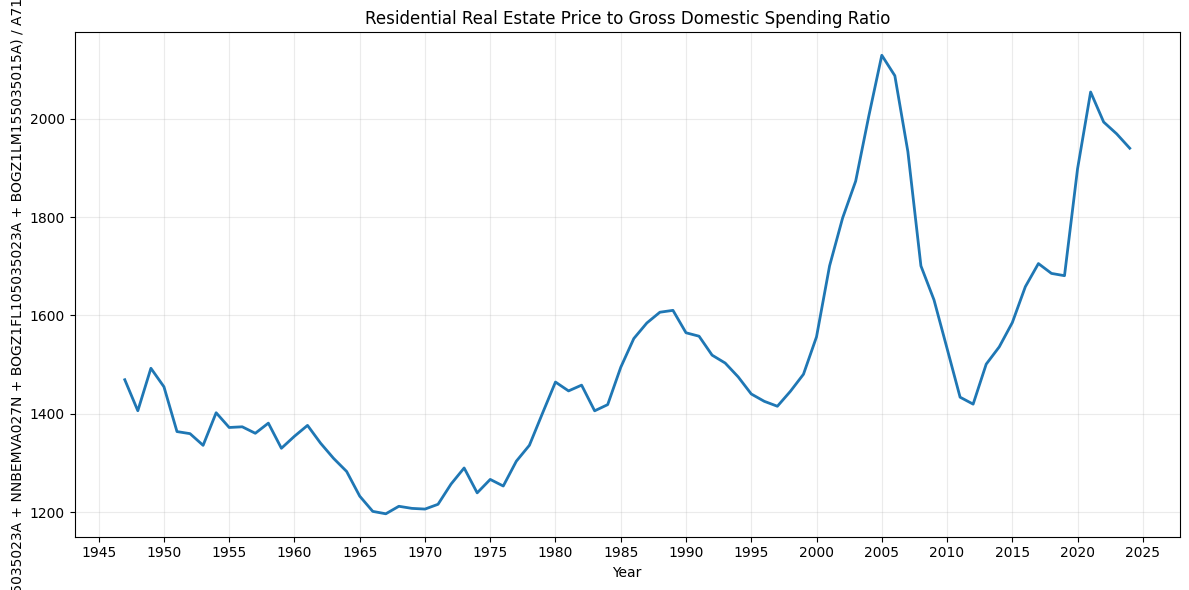

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


BOGZ1FL165035023A = to_annual(fred_series("BOGZ1FL165035023A"))
NNBEMVA027N = to_annual(fred_series("NNBEMVA027N"))
BOGZ1FL105035023A = to_annual(fred_series("BOGZ1FL105035023A"))
BOGZ1LM155035015A = to_annual(fred_series("BOGZ1LM155035015A"))
A712RC1A027NBEA = to_annual(fred_series("A712RC1A027NBEA"))

rre_ratio_df = pd.concat(
    [
        BOGZ1FL165035023A,
        NNBEMVA027N,
        BOGZ1FL105035023A,
        BOGZ1LM155035015A,
        A712RC1A027NBEA,
    ],
    axis=1,
).dropna()
rre_ratio_df = rre_ratio_df[rre_ratio_df["A712RC1A027NBEA"] != 0]
rre_ratio_df["RRE_Price_to_GDS_Ratio"] = (
    rre_ratio_df["BOGZ1FL165035023A"]
    + rre_ratio_df["NNBEMVA027N"]
    + rre_ratio_df["BOGZ1FL105035023A"]
    + rre_ratio_df["BOGZ1LM155035015A"]
) / rre_ratio_df["A712RC1A027NBEA"]

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2024", freq="Y")
rre_price_to_gds_ratio = rre_ratio_df.loc[start_y:end_y, "RRE_Price_to_GDS_Ratio"].dropna()

plot = rre_price_to_gds_ratio.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
ax.set_title("Residential Real Estate Price to Gross Domestic Spending Ratio")
ax.set_xlabel("Year")
ax.set_ylabel(
    "(BOGZ1FL165035023A + NNBEMVA027N + BOGZ1FL105035023A + BOGZ1LM155035015A) / A712RC1A027NBEA"
)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


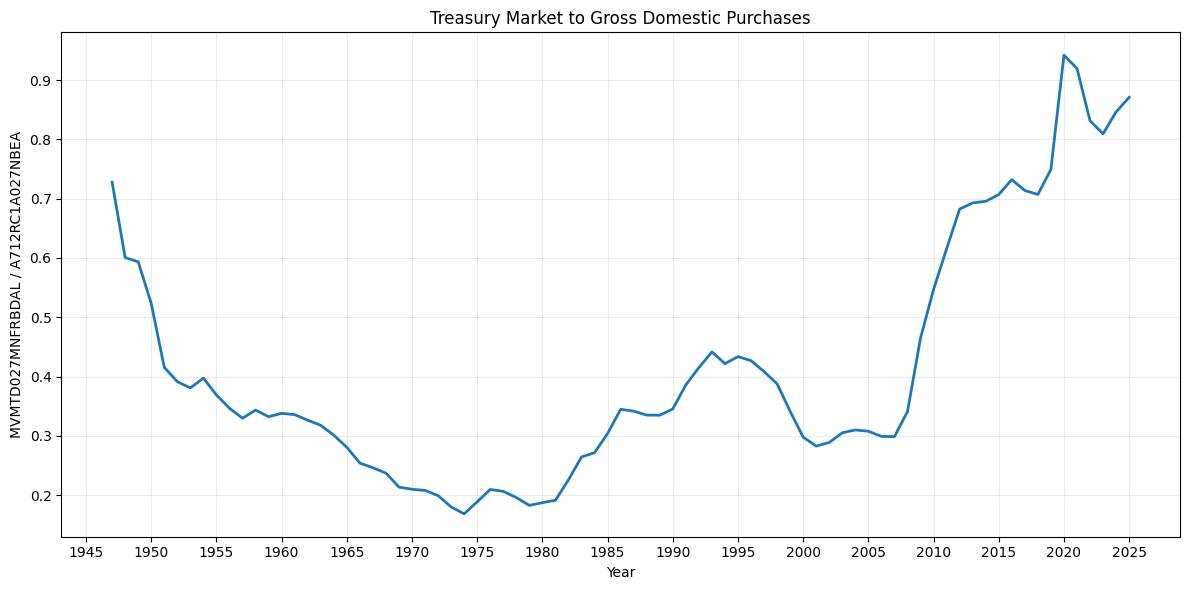

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual_mean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    # For monthly data, this is the average over months in each year.
    return out.groupby(level=0).mean()


MVMTD027MNFRBDAL = to_annual_mean(fred_series("MVMTD027MNFRBDAL"))
A712RC1A027NBEA = to_annual_mean(fred_series("A712RC1A027NBEA"))

ratio_df = pd.concat([MVMTD027MNFRBDAL, A712RC1A027NBEA], axis=1).dropna()
ratio_df = ratio_df[ratio_df["A712RC1A027NBEA"] != 0]
ratio_df["Treasury_Market_to_GDP_Ratio"] = (
    ratio_df["MVMTD027MNFRBDAL"] / ratio_df["A712RC1A027NBEA"]
)

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2025", freq="Y")
treasury_market_to_gdp_ratio = ratio_df.loc[start_y:end_y, "Treasury_Market_to_GDP_Ratio"].dropna()

plot = treasury_market_to_gdp_ratio.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
ax.set_title("Treasury Market to Gross Domestic Purchases")
ax.set_xlabel("Year")
ax.set_ylabel("MVMTD027MNFRBDAL / A712RC1A027NBEA")
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()
